### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import pandas as pd

### Day 2: Exercise 3

#### 3.1. Simulated Value Generation

<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_36882/3071688213.py:32: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Exponential Distribution ($\lambda=4$)')


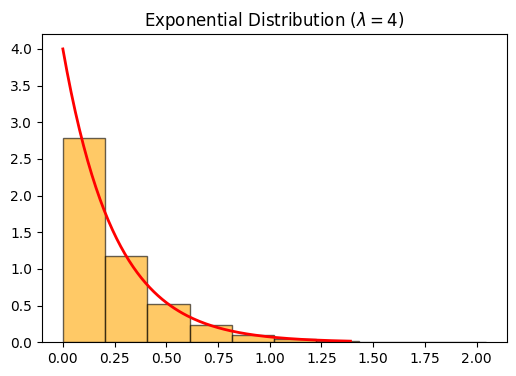

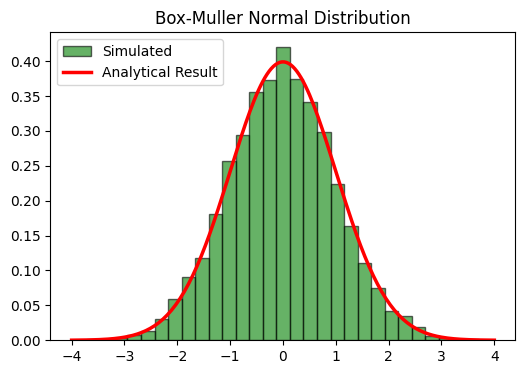

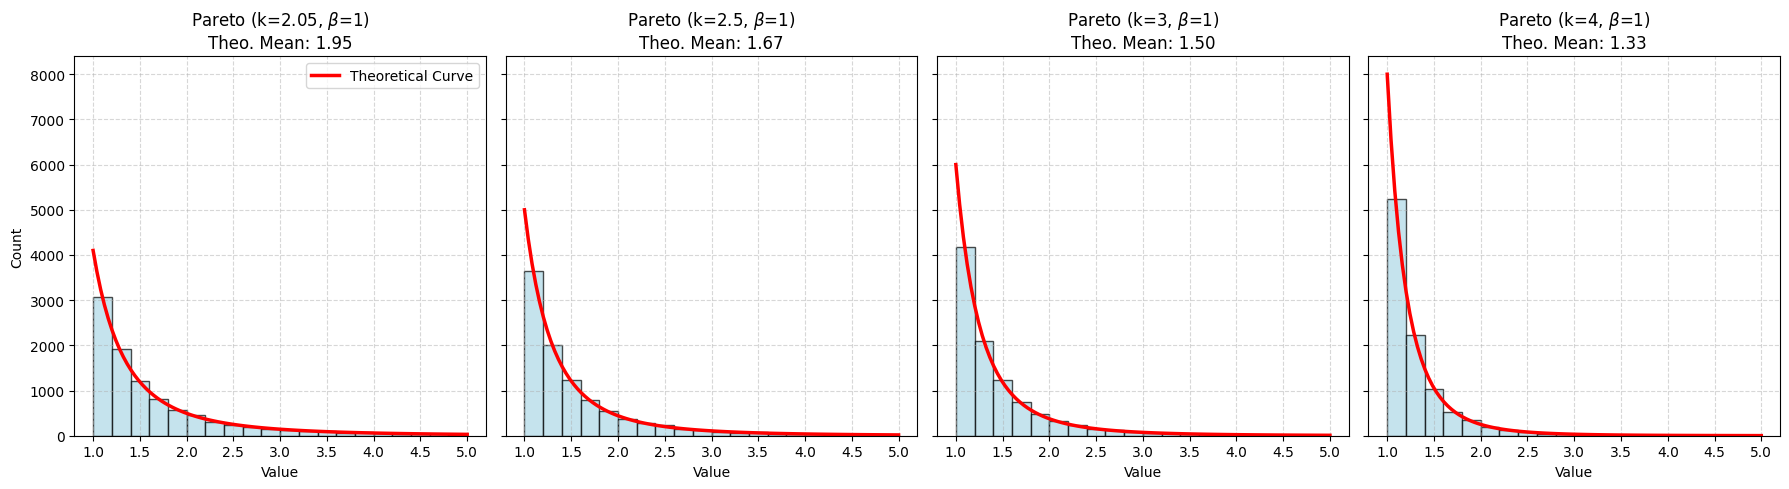

,k,Theo. Mean,Sim. Mean,Theo. Var,Sim. Var,K-S p-value
0,2.05,1.952381,1.939959,37.188209,7.065429,0.660586
1,2.50,1.666667,1.683148,2.222222,3.279423,0.851381
2,3.00,1.500000,1.505962,0.750000,0.809762,0.330963
3,4.00,1.333333,1.333289,0.222222,0.246911,0.485862



             Kalmagorov-Smirnov test summary
Exponential K-S Test: p-value = 0.0859
Normal K-S Test:      p-value = 0.0524
Pareto (k=2.05) K-S Test: p-value = 0.6606 (Fits Distribution)
Pareto (k=2.5 ) K-S Test: p-value = 0.8514 (Fits Distribution)
Pareto (k=3   ) K-S Test: p-value = 0.3310 (Fits Distribution)
Pareto (k=4   ) K-S Test: p-value = 0.4859 (Fits Distribution)


In [11]:
np.random.seed(42)  
SAMPLE_SIZE = 10000
ks_summary_log = [] 


# Sampling functions
def box_muller_numpy(n_samples):
    if n_samples % 2 != 0:
        n_samples += 1
    num_pairs = n_samples // 2
    u1 = 1.0 - np.random.uniform(0, 1, num_pairs)
    u2 = np.random.uniform(0, 1, num_pairs)
    
    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2
    return np.concatenate([r * np.cos(theta), r * np.sin(theta)])

def pareto_sampling(n_samples, beta, k):
    u = np.random.uniform(0, 1, n_samples)
    return beta * (u ** (-1.0 / k))


# Exponential Distribution
lamb = 4
wait_times = stats.expon.rvs(loc=0, scale=1/lamb, size=SAMPLE_SIZE)

# Plotting
plt.figure(figsize=(6, 4))
plt.hist(wait_times, density=True, alpha=0.6, color='orange', edgecolor='black')
x = np.arange(0, 1.4, 0.01)
plt.plot(x, stats.expon.pdf(x, loc=0, scale=1/lamb), color='red', lw=2)
plt.title('Exponential Distribution ($\lambda=4$)')
plt.show()

# Record K-S Test
_, p_val_exp = stats.kstest(wait_times, stats.expon.cdf, args=(0, 1/lamb))
ks_summary_log.append(f"Exponential K-S Test: p-value = {p_val_exp:.4f}")


# Normal Distribution, with Box-Muller

normal_samples = box_muller_numpy(SAMPLE_SIZE)

# Plotting
plt.figure(figsize=(6, 4))
plt.hist(normal_samples, bins=30, density=True, alpha=0.6, color='g', edgecolor='black', label='Simulated')
x_vals = np.linspace(-4, 4, 200)
plt.plot(x_vals, stats.norm.pdf(x_vals, loc=0, scale=1), color='red', lw=2.5, label='Analytical Result')
plt.legend(loc='upper left')
plt.title('Box-Muller Normal Distribution')
plt.show()

# Record K-S Test
_, p_val_norm = stats.kstest(normal_samples, stats.norm.cdf)
ks_summary_log.append(f"Normal K-S Test:      p-value = {p_val_norm:.4f}")


# Pareto Distribution

k_values = [2.05, 2.5, 3, 4]
xmin, xmax = 1, 5
num_bins = 20
bin_width = (xmax - xmin) / num_bins 
pareto_results = []

fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5), sharey=True)

for ax, k in zip(axes, k_values):
    data = pareto_sampling(SAMPLE_SIZE, beta=1, k=k)
    
    # Plot data histogram
    ax.hist(data, bins=num_bins, range=(xmin, xmax), alpha=0.7, color='lightblue', edgecolor='black')
    
    # Calculate Stats
    sim_mean = np.mean(data)
    sim_var = np.var(data, ddof=1)
    theo_mean = (1 * k) / (k - 1) if k > 1 else np.inf
    theo_var = (1**2 * k) / ((k - 1)**2 * (k - 2)) if k > 2 else np.inf

    # Record K-S Test
    _, p_val_par = stats.kstest(data, 'pareto', args=(k, 0, 1))
    status = "Fits Distribution" if p_val_par >= 0.05 else "Does Not Fit Distribution"
    ks_summary_log.append(f"Pareto (k={k:<4}) K-S Test: p-value = {p_val_par:.4f} ({status})")

    pareto_results.append({
        "k": k, "Theo. Mean": theo_mean, "Sim. Mean": sim_mean,
        "Theo. Var": theo_var, "Sim. Var": sim_var, "K-S p-value": p_val_par
    })

    # Overlay Theoretical Curve
    x_vals = np.linspace(xmin, xmax, 100)
    scaled_pdf = stats.pareto.pdf(x_vals, b=k, scale=1) * SAMPLE_SIZE * bin_width
    ax.plot(x_vals, scaled_pdf, 'r-', lw=2.5, label='Theoretical Curve')

    ax.set_title(f"Pareto (k={k}, $\\beta$=1)\nTheo. Mean: {theo_mean:,.2f}")
    ax.set_xlabel("Value")
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_ylabel("Count")
axes[0].legend()
plt.tight_layout()
plt.show()

# Summary of the K-S test result

display(pd.DataFrame(pareto_results))

print("\n" + "="*60)
print("             Kalmagorov-Smirnov test summary")
print("="*60)
for log in ks_summary_log:
    print(log)
print("="*60)

### 3.2. Normal distribution generation

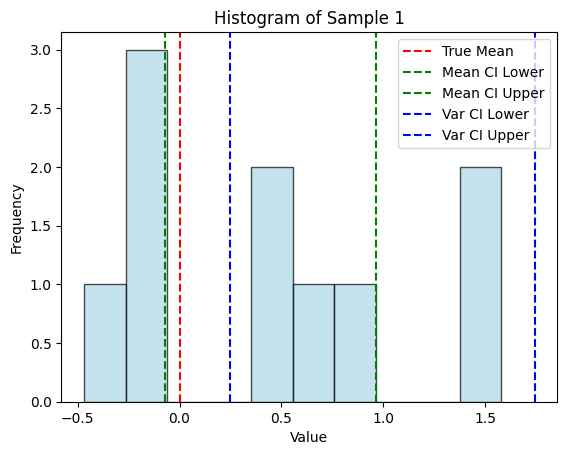

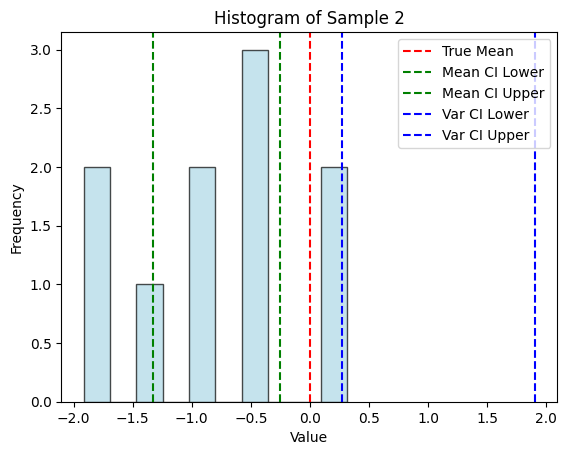

--- Summary over 100 Runs ---
Mean CI Capture Rate: 95.0% (Expected: ~95%)
Variance CI Capture Rate: 97.0% (Expected: ~95%)

--- First 5 Simulation Runs ---
 Run  Sample Mean         Mean CI  Sample Var    Variance CI
   1     0.448061 (-0.069, 0.965)    0.522741 (0.247, 1.742)
   2    -0.790658 (-1.331, -0.25)    0.570515  (0.27, 1.901)
   3    -0.221844  (-0.804, 0.36)    0.662430 (0.313, 2.208)
   4    -0.310107 (-1.129, 0.509)    1.311562 (0.621, 4.371)
   5    -0.252822 (-0.897, 0.391)    0.811092 (0.384, 2.703)


In [12]:
np.random.seed(42)

n = 10
df = n - 1
n_simulations = 100

# True population parameters
true_mean = 0
true_var = 1

results = []

for i in range(n_simulations):
    # Generate 10 observations from standard normal distribution
    data = np.random.normal(loc=true_mean, scale=np.sqrt(true_var), size=n)
    
    sample_mean = np.mean(data)
    sample_var = np.var(data, ddof=1)
    sample_std = np.std(data, ddof=1)

    # 95% Confidence Interval for the mean, using t-distribution
    # t critical value for 95% confidence and 9 degrees of freedom (~2.262)
    t_crit = stats.t.ppf(0.975, df=df)
    mean_sem = sample_std / np.sqrt(n)
    
    mean_ci_lower = sample_mean - (t_crit * mean_sem)
    mean_ci_upper = sample_mean + (t_crit * mean_sem)

    # 95% Confidence Interval for the variance (Using Chi-Squared)
    # Chi-squared critical values for 95% confidence and 9 degrees of freedom
    chi2_lower = stats.chi2.ppf(0.025, df=df)
    chi2_upper = stats.chi2.ppf(0.975, df=df)
    
    var_ci_lower = (df * sample_var) / chi2_upper
    var_ci_upper = (df * sample_var) / chi2_lower
    
    mean_captured = (mean_ci_lower <= true_mean <= mean_ci_upper)
    var_captured = (var_ci_lower <= true_var <= var_ci_upper)
    
    results.append({
        "Run": i + 1,
        "Sample Mean": sample_mean,
        "Mean CI": (round(mean_ci_lower, 3), round(mean_ci_upper, 3)),
        "Mean Captured": mean_captured,
        "Sample Var": sample_var,
        "Variance CI": (round(var_ci_lower, 3), round(var_ci_upper, 3)),
        "Var Captured": var_captured
    })

    if i < 2:
        plt.hist(data, alpha=0.7, color='lightblue', edgecolor='black')
        plt.axvline(x=true_mean, color='red', linestyle='--', label='True Mean')
        plt.axvline(x=mean_ci_lower, color='green', linestyle='--', label='Mean CI Lower')
        plt.axvline(x=mean_ci_upper, color='green', linestyle='--', label='Mean CI Upper')
        plt.axvline(x=var_ci_lower, color='blue', linestyle='--', label='Var CI Lower')
        plt.axvline(x=var_ci_upper, color='blue', linestyle='--', label='Var CI Upper')
        plt.title(f"Histogram of Sample {i + 1}")
        plt.xlabel("Value")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Display Summary Metrics
print(f"--- Summary over {n_simulations} Runs ---")
print(f"Mean CI Capture Rate: {df_results['Mean Captured'].mean() * 100:.1f}% (Expected: ~95%)")
print(f"Variance CI Capture Rate: {df_results['Var Captured'].mean() * 100:.1f}% (Expected: ~95%)")
print("\n--- First 5 Simulation Runs ---")
print(df_results[['Run', 'Sample Mean', 'Mean CI', 'Sample Var', 'Variance CI']].head().to_string(index=False))


# Note: Central Limit Theorem example, the more data we would have, the more accurate estimates of CI would be for the mean and the variance

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\c'
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_36882/3260739412.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax1.axvline(x=TRUE_MEAN, color='black', linestyle='--', lw=2, label=f'True Mean ($\mu$ = {TRUE_MEAN})')
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_36882/3260739412.py:47: SyntaxWarning: invalid escape sequence '\s'
  ax2.axvline(x=TRUE_VAR, color='black', linestyle='--', lw=2, label=f'True Variance ($\sigma^2$ = {TRUE_VAR})')
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_36882/3260739412.py:49: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_title(f'95% Variance CI ($\chi^2$-dist, $df$=9)\nCapture Rate: {var_rate:.1f}%', fon

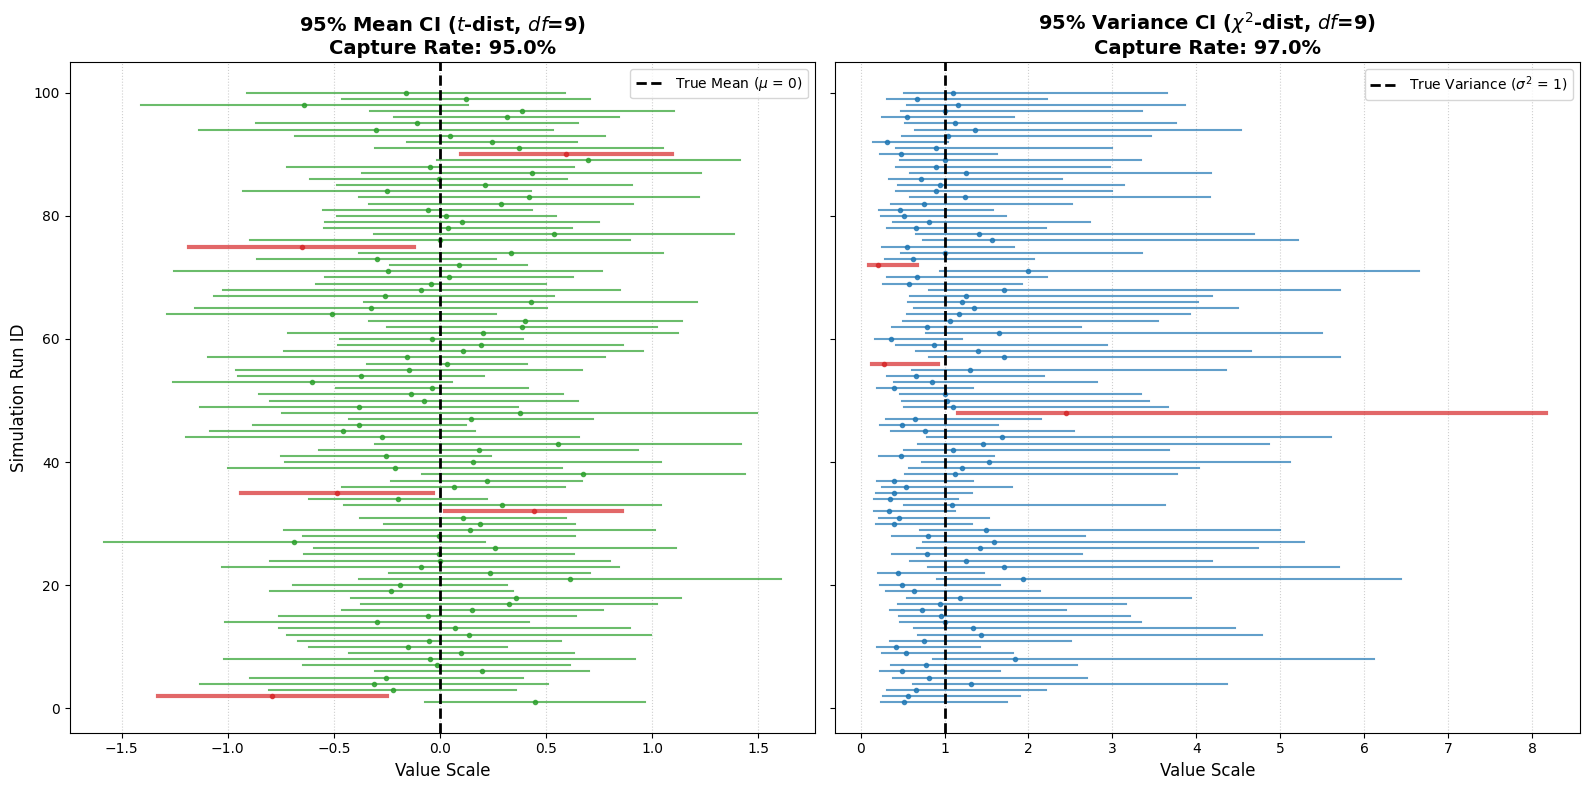

In [13]:
runs = df_results['Run'].values
sample_means = df_results['Sample Mean'].values
sample_vars = df_results['Sample Var'].values

# Extract lower and upper bounds from the tuples in your dataframe
mean_lowers = np.array([ci[0] for ci in df_results['Mean CI']])
mean_uppers = np.array([ci[1] for ci in df_results['Mean CI']])
mean_captured = df_results['Mean Captured'].values

var_lowers = np.array([ci[0] for ci in df_results['Variance CI']])
var_uppers = np.array([ci[1] for ci in df_results['Variance CI']])
var_captured = df_results['Var Captured'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# POPULATION TARGETS
TRUE_MEAN = 0
TRUE_VAR = 1

# --- Panel 1: Mean Confidence Intervals ---
for i in range(len(runs)):
    color = '#2ca02c' if mean_captured[i] else '#d62728'
    linewidth = 1.5 if mean_captured[i] else 3.0
    
    # Plot the line segment representing the CI
    ax1.plot([mean_lowers[i], mean_uppers[i]], [runs[i], runs[i]], color=color, alpha=0.7, lw=linewidth)
    # Plot a small dot for the sample mean point estimate
    ax1.plot(sample_means[i], runs[i], 'o', color=color, markersize=3, alpha=0.8)

ax1.axvline(x=TRUE_MEAN, color='black', linestyle='--', lw=2, label=f'True Mean ($\mu$ = {TRUE_MEAN})')
mean_rate = mean_captured.mean() * 100
ax1.set_title(True, fontsize=13, pad=10)
ax1.set_title(f'95% Mean CI ($t$-dist, $df$=9)\nCapture Rate: {mean_rate:.1f}%', fontsize=14, fontweight='bold')
ax1.set_xlabel('Value Scale', fontsize=12)
ax1.set_ylabel('Simulation Run ID', fontsize=12)
ax1.grid(axis='x', linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# --- Panel 2: Variance Confidence Intervals ---
for i in range(len(runs)):
    color = '#1f77b4' if var_captured[i] else '#d62728'
    linewidth = 1.5 if var_captured[i] else 3.0
    
    ax2.plot([var_lowers[i], var_uppers[i]], [runs[i], runs[i]], color=color, alpha=0.7, lw=linewidth)
    ax2.plot(sample_vars[i], runs[i], 'o', color=color, markersize=3, alpha=0.8)

ax2.axvline(x=TRUE_VAR, color='black', linestyle='--', lw=2, label=f'True Variance ($\sigma^2$ = {TRUE_VAR})')
var_rate = var_captured.mean() * 100
ax2.set_title(f'95% Variance CI ($\chi^2$-dist, $df$=9)\nCapture Rate: {var_rate:.1f}%', fontsize=14, fontweight='bold')
ax2.set_xlabel('Value Scale', fontsize=12)
ax2.grid(axis='x', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('confidence_intervals_summary.png', bbox_inches='tight', dpi=300)
plt.show()

### Simulation of Pareto Distribution using composition

In [14]:
def pareto_composition_sampling(n_samples, beta, k, standard=True):
    """
    Simulates a Pareto distribution using the Composition Method.
    """
    # Generate Y from f_Y(y) -> Gamma(shape=k, rate=beta)
    gamma_scale = 1.0 / beta
    y = np.random.gamma(shape=k, scale=gamma_scale, size=n_samples)
    print(y[:5])  # Print first 5 samples of Y for verification

    # Generate X from f_X|Y (x | Y = y) -> Exponential(rate=y)
    x_conditional = np.random.exponential(scale=1.0 / y)
    print(x_conditional[:5])  # Print first 5 samples of X|Y for verification
    
    if standard:
        return x_conditional + beta
    else:
        return x_conditional

# Verification Simulation
n_samples = 100000
beta = 2.0
k = 3.0

# Generate using composition method
samples = pareto_composition_sampling(n_samples, beta, k, standard=True)

# Compare against the Pareto mean
simulated_mean = np.mean(samples)
theoretical_mean = (beta * k) / (k - 1)

print(f"--- Composition Method Verification (k={k}, beta={beta}) ---")
print(f"Minimum Value in Samples: {np.min(samples):.4f} (Expected Beta: {beta})")
print(f"Simulated Sample Mean:    {simulated_mean:.4f}")
print(f"Theoretical Pareto Mean:  {theoretical_mean:.4f}")

[2.83334283 2.23974942 1.38261636 0.87179571 2.20595263]
[0.10471052 0.14620762 0.09353091 2.85647343 0.73219885]
--- Composition Method Verification (k=3.0, beta=2.0) ---
Minimum Value in Samples: 2.0000 (Expected Beta: 2.0)
Simulated Sample Mean:    2.9939
Theoretical Pareto Mean:  3.0000
